# Model 5 — Selective Semi-Frozen Fusion

Notebook ini menjalankan Model 5 Fusion Text + Sequence LSTM untuk TCSSC. Model dirancang untuk menjaga pipeline utama: text branch, tool-call sequence branch, dan fusion classifier, tetapi training dibuat lebih efisien dengan hanya melakukan fine-tuning sebagian pada branch BERT yang paling penting.

Ide utama:
1. Whole-sequence branch memakai BERT yang di-fine-tune sebagian.
2. Context branch dan per-tool-call sequence branch memakai frozen BERT embedding yang di-cache.
3. Sequence branch diproses dengan BiLSTM dan attention pooling.
4. Fusion classifier menggabungkan context vector, sequence vector, dan whole-sequence BERT vector.

Strategi ini mempertahankan tujuan Model 5: menggabungkan text signal dan tool-call sequence signal untuk klasifikasi 4 kelas TCSSC.

## 1. Persiapan Environment

Bagian ini memasang dependency dan menyiapkan konfigurasi dasar notebook.

### 1.1 Install Dependency

Cell ini memasang library utama untuk pemrosesan dataset, training PyTorch, model Transformer, dan evaluasi.

In [1]:
!pip install -q transformers==4.40.0 torch scikit-learn pandas numpy tqdm matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 101.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 98.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
sentence-transformers 5.4.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 

### 1.2 Import Library

Cell ini memuat library yang digunakan pada seluruh notebook.

In [2]:
import os
import json
import time
import random
import hashlib
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

### 1.3 Konfigurasi Eksperimen

Parameter utama diselaraskan dengan eksperimen Model 1: BERT multilingual, panjang sequence 256, batch size 16, 15 epoch, dan early stopping 5. Perbedaannya, model ini memakai selective semi-frozen BERT hanya pada whole-sequence branch.

In [3]:
SEED = 42
ENCODER_MODEL = "bert-base-multilingual-cased"

MAX_SEQ_LEN = 256
MAX_TOOL_CALLS = 20
BATCH_SIZE = 16
LEARNING_RATE_BERT = 2e-5
LEARNING_RATE_HEAD = 2e-4
NUM_EPOCHS = 15
WEIGHT_DECAY = 1e-4
EARLY_STOP = 5

UNFREEZE_LAST_N_LAYERS = 4
ENCODER_BATCH_SIZE = 64
EMBEDDING_BATCH_SIZE = 128

LSTM_HIDDEN_SIZE = 256
LSTM_NUM_LAYERS = 2
FUSION_DIM = 256
DROPOUT = 0.25
USE_AMP = True

LABEL2ID = {
  "benign": 0,
  "direct_attack": 1,
  "sequential_attack": 2,
  "parameter_injection": 3,
}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
NUM_CLASSES = len(LABEL2ID)

CHECKPOINT_DIR = Path("./checkpoints")
OUTPUT_DIR = Path("./outputs")
CACHE_DIR = Path("./cache_model5_selective_fusion")

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### 1.4 Reproducibility dan Cek GPU

Cell ini mengatur seed dan memastikan GPU terdeteksi sebelum training dijalankan.

In [4]:
def set_seed(seed: int = 42):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)

set_seed(SEED)

print("Device:", DEVICE)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
if torch.cuda.is_available():
  for i in range(torch.cuda.device_count()):
    print(f"GPU {i}:", torch.cuda.get_device_name(i))

Device: cuda
CUDA available: True
CUDA device count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4


## 2. Load dan Validasi Dataset

Bagian ini membaca dataset TCSSC dan memvalidasi kolom serta label yang dipakai.

### 2.1 Menentukan Path Dataset

Cell ini mencari dataset pada beberapa lokasi umum Kaggle, Colab, dan direktori kerja lokal.

In [5]:
candidate_paths = [
  "/kaggle/input/datasets/raditya0/tcssc-dataset/tcssc_dataset.csv",
  "/kaggle/input/tcssc-dataset/tcssc_dataset.csv",
  "/kaggle/input/tcssc_dataset/tcssc_dataset.csv",
  "/content/tcssc_dataset.csv",
  "./tcssc_dataset.csv",
  "/mnt/data/tcssc_dataset.csv",
]

DATASET_PATH = None
for path in candidate_paths:
  if Path(path).exists():
    DATASET_PATH = path
    break

if DATASET_PATH is None:
  raise FileNotFoundError("Dataset tidak ditemukan. Ubah DATASET_PATH ke lokasi tcssc_dataset.csv.")

print("Dataset path:", DATASET_PATH)

Dataset path: /kaggle/input/datasets/raditya0/tcssc-dataset/tcssc_dataset.csv


### 2.2 Membaca Dataset

Cell ini membaca dataset dan menjaga hanya label yang termasuk dalam skema multiclass TCSSC.

In [6]:
df = pd.read_csv(DATASET_PATH)
required_columns = ["tool_calls_json", "tool_calls_text", "label", "source", "context_text"]
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
  raise ValueError(f"Kolom berikut tidak ditemukan: {missing_columns}")

df = df[df["label"].isin(LABEL2ID)].copy()
df["context_text"] = df["context_text"].fillna("")
df["tool_calls_json"] = df["tool_calls_json"].fillna("[]")

print("Shape:", df.shape)
print("Label distribution:")
print(df["label"].value_counts())

Shape: (9990, 5)
Label distribution:
label
sequential_attack      2893
benign                 2500
parameter_injection    2300
direct_attack          2297
Name: count, dtype: int64


## 3. Preprocessing dan Split Data

Bagian ini membangun tiga representasi: context text, per-tool-call sequence, dan whole sequence text.

### 3.1 Fungsi Preprocessing Tool Call

Cell ini mengubah JSON tool call menjadi teks yang bisa diproses BERT.

In [7]:
def safe_json_loads(value):
  try:
    parsed = json.loads(str(value))
    return parsed if isinstance(parsed, list) else []
  except Exception:
    return []


def normalize_tool_call(tc):
  if not isinstance(tc, dict):
    return {"name": "unknown", "params": {"raw": str(tc)}}
  name = str(tc.get("name", tc.get("function", "unknown"))).lower().strip()
  params = tc.get("parameters", tc.get("arguments", tc.get("args", tc.get("params", {}))))
  if isinstance(params, str):
    try:
      params = json.loads(params)
    except Exception:
      params = {"raw": params}
  return {"name": name, "params": params}


def flatten_params(params, max_keys=24):
  if not isinstance(params, dict):
    return str(params)[:500]
  parts = []
  for i, (key, value) in enumerate(params.items()):
    if i >= max_keys:
      break
    parts.append(f"{key}={str(value)[:160]}")
  return " | ".join(parts)


def tool_call_to_text(tc):
  normalized = normalize_tool_call(tc)
  return f"[FUNC] {normalized['name']} [ARGS] {flatten_params(normalized['params'])}"

### 3.2 Membuat Representasi Model 5

Setiap sampel dibuat menjadi context branch, sequence branch, dan whole-sequence branch. MAX_TOOL_CALLS diset 20 agar sejajar dengan Model 1 dan tidak memotong sequence panjang di dataset.

In [8]:
def build_sample_representation(row):
  sequence = safe_json_loads(row["tool_calls_json"])
  raw_call_texts = [tool_call_to_text(tc) for tc in sequence[:MAX_TOOL_CALLS]]
  call_mask = [1] * len(raw_call_texts)

  if len(raw_call_texts) < MAX_TOOL_CALLS:
    pad_count = MAX_TOOL_CALLS - len(raw_call_texts)
    raw_call_texts = raw_call_texts + [""] * pad_count
    call_mask = call_mask + [0] * pad_count

  context_text = str(row["context_text"])
  non_empty_calls = [text for text, mask in zip(raw_call_texts, call_mask) if mask == 1]
  whole_sequence_text = context_text + " [TOOL_SEQUENCE] " + " ".join(non_empty_calls)

  return {
    "context_text": context_text,
    "call_texts": raw_call_texts,
    "call_mask": call_mask,
    "whole_sequence_text": whole_sequence_text,
    "label_id": LABEL2ID[str(row["label"])],
    "label": str(row["label"]),
    "source": str(row["source"]),
  }

records = [build_sample_representation(row) for _, row in df.iterrows()]
processed_df = pd.DataFrame(records)

print("Processed shape:", processed_df.shape)
processed_df.head(3)

Processed shape: (9990, 7)


,context_text,call_texts,call_mask,whole_sequence_text,label_id,label,source
0,user: Can you check my Alipay balance and also...,[[FUNC] checkaccountbalanceapi [ARGS] user_id=...,"[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",user: Can you check my Alipay balance and also...,1,direct_attack,safetoolbench
1,user: Set a reminder for my doctor's appointme...,[[FUNC] createediteventapi [ARGS] event_title=...,"[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",user: Set a reminder for my doctor's appointme...,1,direct_attack,safetoolbench
2,user: Delete the folder containing all my pers...,[[FUNC] deletefileapi [ARGS] file_id=folder_id...,"[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",user: Delete the folder containing all my pers...,1,direct_attack,safetoolbench


### 3.3 Stratified Split

Split dibuat 70/15/15 agar hasil tetap sebanding dengan eksperimen lain.

In [9]:
train_df, temp_df = train_test_split(
  processed_df,
  test_size=0.30,
  random_state=SEED,
  stratify=processed_df["label_id"],
)
val_df, test_df = train_test_split(
  temp_df,
  test_size=0.50,
  random_state=SEED,
  stratify=temp_df["label_id"],
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 6993
Validation: 1498
Test: 1499


## 4. Tokenizer dan Frozen Embedding Cache

Bagian ini membuat frozen embedding untuk context branch dan per-tool-call branch. Embedding ini tidak di-fine-tune agar training tidak terlalu berat.

### 4.1 Memuat Tokenizer

Tokenizer yang sama dipakai untuk frozen branch dan semi-frozen branch.

In [10]:
tokenizer = AutoTokenizer.from_pretrained(ENCODER_MODEL)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

### 4.2 Fungsi Unique Text Embedding

Cell ini membuat embedding untuk teks unik saja agar padding dan teks berulang tidak dihitung berkali-kali.

In [11]:
def get_underlying_module(model):
  return model.module if isinstance(model, nn.DataParallel) else model


def get_cls_embeddings_for_unique_texts(texts, max_len=MAX_SEQ_LEN, batch_size=64):
  unique_texts = list(dict.fromkeys([str(text) for text in texts]))
  text_to_index = {text: idx for idx, text in enumerate(unique_texts)}

  encoder = AutoModel.from_pretrained(ENCODER_MODEL)
  for parameter in encoder.parameters():
    parameter.requires_grad = False
  encoder.eval()
  encoder.to(DEVICE)
  if torch.cuda.device_count() > 1:
    encoder = nn.DataParallel(encoder)

  unique_embeddings = []
  for start in tqdm(range(0, len(unique_texts), batch_size), desc="Frozen BERT embeddings"):
    batch_texts = unique_texts[start:start + batch_size]
    encoded = tokenizer(
      batch_texts,
      max_length=max_len,
      padding=True,
      truncation=True,
      return_tensors="pt",
    )
    encoded = {key: value.to(DEVICE) for key, value in encoded.items()}
    with torch.no_grad():
      with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
        outputs = encoder(**encoded)
        cls_embedding = outputs.last_hidden_state[:, 0, :].detach().cpu()
    unique_embeddings.append(cls_embedding)

  unique_embeddings = torch.cat(unique_embeddings, dim=0)
  ordered_indices = torch.tensor([text_to_index[str(text)] for text in texts], dtype=torch.long)
  embeddings = unique_embeddings[ordered_indices]

  del encoder
  if torch.cuda.is_available():
    torch.cuda.empty_cache()

  return embeddings

### 4.3 Cache Signature

Signature memastikan cache berbeda ketika konfigurasi penting berubah.

In [12]:
def make_cache_signature():
  raw = json.dumps({
    "dataset_path": str(DATASET_PATH),
    "num_rows": len(processed_df),
    "encoder_model": ENCODER_MODEL,
    "max_seq_len": MAX_SEQ_LEN,
    "max_tool_calls": MAX_TOOL_CALLS,
    "seed": SEED,
    "plan": "selective_fusion_selective_semifrozen",
  }, sort_keys=True)
  return hashlib.md5(raw.encode("utf-8")).hexdigest()[:12]

CACHE_SIGNATURE = make_cache_signature()
CACHE_PATH = CACHE_DIR / f"frozen_embeddings_{CACHE_SIGNATURE}.pt"
print("Cache path:", CACHE_PATH)

Cache path: cache_model5_selective_fusion/frozen_embeddings_9a91a84482ed.pt


### 4.4 Ekstraksi Frozen Embedding

Cell ini membuat atau memuat cache embedding untuk context branch dan sequence branch.

In [13]:
def extract_frozen_embeddings(dataframe):
  context_texts = dataframe["context_text"].tolist()
  context_embeddings = get_cls_embeddings_for_unique_texts(
    context_texts,
    max_len=MAX_SEQ_LEN,
    batch_size=ENCODER_BATCH_SIZE,
  )

  flat_call_texts = []
  for call_texts in dataframe["call_texts"]:
    flat_call_texts.extend(call_texts)

  flat_call_embeddings = get_cls_embeddings_for_unique_texts(
    flat_call_texts,
    max_len=MAX_SEQ_LEN,
    batch_size=ENCODER_BATCH_SIZE,
  )
  call_embeddings = flat_call_embeddings.view(len(dataframe), MAX_TOOL_CALLS, -1)

  call_masks = torch.tensor(dataframe["call_mask"].tolist(), dtype=torch.float32)
  labels = torch.tensor(dataframe["label_id"].tolist(), dtype=torch.long)

  return {
    "context_embeddings": context_embeddings,
    "call_embeddings": call_embeddings,
    "call_masks": call_masks,
    "labels": labels,
  }

if CACHE_PATH.exists():
  embedding_data = torch.load(CACHE_PATH, map_location="cpu")
  print("Loaded frozen embedding cache")
else:
  all_df = pd.concat([train_df, val_df, test_df], axis=0).reset_index(drop=True)
  embedding_data_all = extract_frozen_embeddings(all_df)
  n_train = len(train_df)
  n_val = len(val_df)
  embedding_data = {
    "train": {key: value[:n_train] for key, value in embedding_data_all.items()},
    "val": {key: value[n_train:n_train + n_val] for key, value in embedding_data_all.items()},
    "test": {key: value[n_train + n_val:] for key, value in embedding_data_all.items()},
  }
  torch.save(embedding_data, CACHE_PATH)
  print("Saved frozen embedding cache")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Frozen BERT embeddings:   0%|          | 0/116 [00:00<?, ?it/s]

2026-06-20 23:13:05.748403: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781997185.990674      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781997186.062632      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781997186.659927      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781997186.659954      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781997186.659956      23 computation_placer.cc:177] computation placer alr

Frozen BERT embeddings:   0%|          | 0/161 [00:00<?, ?it/s]

Saved frozen embedding cache


## 5. Whole-Sequence Tokenization

Bagian ini menyiapkan input untuk BERT branch yang di-fine-tune sebagian. Branch ini membaca context dan seluruh tool-call sequence sebagai satu teks.

### 5.1 Batch Tokenization

Tokenisasi dilakukan sebelum training agar DataLoader tidak lambat karena tokenisasi berulang.

In [14]:
def tokenize_whole_texts(texts):
  encoded = tokenizer(
    list(texts),
    max_length=MAX_SEQ_LEN,
    padding="max_length",
    truncation=True,
    return_tensors="pt",
  )
  return {
    "input_ids": encoded["input_ids"],
    "attention_mask": encoded["attention_mask"],
  }

whole_tokens = {
  "train": tokenize_whole_texts(train_df["whole_sequence_text"].tolist()),
  "val": tokenize_whole_texts(val_df["whole_sequence_text"].tolist()),
  "test": tokenize_whole_texts(test_df["whole_sequence_text"].tolist()),
}

print("Whole-sequence tokens ready")

Whole-sequence tokens ready


## 6. Dataset dan DataLoader

Bagian ini menggabungkan frozen embeddings dengan token whole-sequence untuk training fusion model.

### 6.1 Dataset Class

Dataset mengembalikan context embedding, call embedding, sequence mask, token BERT, dan label.

In [15]:
class SelectiveFusionDataset(Dataset):
  def __init__(self, frozen_data, token_data):
    self.context_embeddings = frozen_data["context_embeddings"].float()
    self.call_embeddings = frozen_data["call_embeddings"].float()
    self.call_masks = frozen_data["call_masks"].float()
    self.labels = frozen_data["labels"].long()
    self.input_ids = token_data["input_ids"].long()
    self.attention_mask = token_data["attention_mask"].long()

  def __len__(self):
    return len(self.labels)

  def __getitem__(self, index):
    return {
      "context_embedding": self.context_embeddings[index],
      "call_embeddings": self.call_embeddings[index],
      "call_mask": self.call_masks[index],
      "input_ids": self.input_ids[index],
      "attention_mask": self.attention_mask[index],
      "label": self.labels[index],
    }

### 6.2 Membuat DataLoader

Batch size 16 diselaraskan dengan eksperimen Model 1.

In [16]:
train_dataset = SelectiveFusionDataset(embedding_data["train"], whole_tokens["train"])
val_dataset = SelectiveFusionDataset(embedding_data["val"], whole_tokens["val"])
test_dataset = SelectiveFusionDataset(embedding_data["test"], whole_tokens["test"])

train_loader = DataLoader(
  train_dataset,
  batch_size=BATCH_SIZE,
  shuffle=True,
  num_workers=0,
  pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
  val_dataset,
  batch_size=BATCH_SIZE,
  shuffle=False,
  num_workers=0,
  pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
  test_dataset,
  batch_size=BATCH_SIZE,
  shuffle=False,
  num_workers=0,
  pin_memory=torch.cuda.is_available(),
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 438
Validation batches: 94
Test batches: 94


## 7. Model 5 

Model ini menggabungkan frozen context branch, frozen per-call sequence branch dengan BiLSTM attention, dan semi-frozen whole-sequence BERT branch.

### 7.1 Fungsi Freeze dan Unfreeze BERT

Cell ini membekukan seluruh BERT lalu membuka beberapa layer terakhir agar adaptasi tetap ringan.

In [17]:
def configure_selective_bert_finetuning(bert_model, unfreeze_last_n_layers=4):
  for parameter in bert_model.parameters():
    parameter.requires_grad = False

  if hasattr(bert_model, "encoder") and hasattr(bert_model.encoder, "layer"):
    for layer in bert_model.encoder.layer[-unfreeze_last_n_layers:]:
      for parameter in layer.parameters():
        parameter.requires_grad = True

  if hasattr(bert_model, "pooler") and bert_model.pooler is not None:
    for parameter in bert_model.pooler.parameters():
      parameter.requires_grad = True

  return bert_model

### 7.2 Arsitektur Selective Fusion

Cell ini mendefinisikan arsitektur model lengkap.

In [18]:
class AttentionPooling(nn.Module):
  def __init__(self, input_dim):
    super().__init__()
    self.score = nn.Linear(input_dim, 1)

  def forward(self, sequence_outputs, mask):
    scores = self.score(sequence_outputs).squeeze(-1)
    scores = scores.masked_fill(mask <= 0, -1e4)
    weights = torch.softmax(scores, dim=1).unsqueeze(-1)
    pooled = (sequence_outputs * weights).sum(dim=1)
    return pooled


class SelectiveSemiFrozenFusionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.whole_encoder = AutoModel.from_pretrained(ENCODER_MODEL)
    self.whole_encoder = configure_selective_bert_finetuning(
      self.whole_encoder,
      unfreeze_last_n_layers=UNFREEZE_LAST_N_LAYERS,
    )

    self.context_projection = nn.Sequential(
      nn.Linear(768, FUSION_DIM),
      nn.LayerNorm(FUSION_DIM),
      nn.GELU(),
      nn.Dropout(DROPOUT),
    )

    self.sequence_lstm = nn.LSTM(
      input_size=768,
      hidden_size=LSTM_HIDDEN_SIZE,
      num_layers=LSTM_NUM_LAYERS,
      batch_first=True,
      dropout=DROPOUT if LSTM_NUM_LAYERS > 1 else 0.0,
      bidirectional=True,
    )
    self.sequence_attention = AttentionPooling(LSTM_HIDDEN_SIZE * 2)
    self.sequence_projection = nn.Sequential(
      nn.Linear(LSTM_HIDDEN_SIZE * 2, FUSION_DIM),
      nn.LayerNorm(FUSION_DIM),
      nn.GELU(),
      nn.Dropout(DROPOUT),
    )

    self.whole_projection = nn.Sequential(
      nn.Linear(768, FUSION_DIM),
      nn.LayerNorm(FUSION_DIM),
      nn.GELU(),
      nn.Dropout(DROPOUT),
    )

    self.classifier = nn.Sequential(
      nn.Linear(FUSION_DIM * 3, FUSION_DIM),
      nn.LayerNorm(FUSION_DIM),
      nn.GELU(),
      nn.Dropout(DROPOUT),
      nn.Linear(FUSION_DIM, NUM_CLASSES),
    )

  def forward(self, batch):
    context_embedding = batch["context_embedding"]
    call_embeddings = batch["call_embeddings"]
    call_mask = batch["call_mask"]
    input_ids = batch["input_ids"]
    attention_mask = batch["attention_mask"]

    context_vector = self.context_projection(context_embedding)

    lengths = call_mask.sum(dim=1).long().clamp(min=1).cpu()
    packed = nn.utils.rnn.pack_padded_sequence(
      call_embeddings,
      lengths,
      batch_first=True,
      enforce_sorted=False,
    )
    packed_outputs, _ = self.sequence_lstm(packed)
    sequence_outputs, _ = nn.utils.rnn.pad_packed_sequence(
      packed_outputs,
      batch_first=True,
      total_length=call_embeddings.size(1),
    )
    sequence_vector = self.sequence_attention(sequence_outputs, call_mask)
    sequence_vector = self.sequence_projection(sequence_vector)

    whole_outputs = self.whole_encoder(input_ids=input_ids, attention_mask=attention_mask)
    whole_cls = whole_outputs.last_hidden_state[:, 0, :]
    whole_vector = self.whole_projection(whole_cls)

    fused_vector = torch.cat([context_vector, sequence_vector, whole_vector], dim=1)
    logits = self.classifier(fused_vector)
    return logits

### 7.3 Inisialisasi Model

Cell ini membuat model, memindahkan ke GPU, dan menampilkan jumlah parameter trainable.

In [19]:
model = SelectiveSemiFrozenFusionModel().to(DEVICE)
if torch.cuda.device_count() > 1:
  model = nn.DataParallel(model)

trainable_params = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
total_params = sum(parameter.numel() for parameter in model.parameters())
print("Trainable parameters:", f"{trainable_params:,}")
print("Total parameters:", f"{total_params:,}")

Trainable parameters: 33,345,797
Total parameters: 182,257,157


## 8. Training dan Evaluasi

Bagian ini melatih model dengan weighted cross entropy dan menyimpan checkpoint terbaik berdasarkan validation weighted F1.

### 8.1 Class Weight dan Optimizer

Cell ini membuat class weight dan optimizer dengan learning rate berbeda untuk BERT layer terakhir dan fusion head.

In [20]:
def compute_class_weights(labels):
  label_counter = Counter(labels.tolist())
  total = len(labels)
  weights = [total / (NUM_CLASSES * label_counter.get(class_id, 1)) for class_id in range(NUM_CLASSES)]
  return torch.tensor(weights, dtype=torch.float32)

class_weights = compute_class_weights(embedding_data["train"]["labels"]).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)

base_model = get_underlying_module(model)
bert_params = []
head_params = []
for name, parameter in base_model.named_parameters():
  if not parameter.requires_grad:
    continue
  if name.startswith("whole_encoder"):
    bert_params.append(parameter)
  else:
    head_params.append(parameter)

optimizer = AdamW(
  [
    {"params": bert_params, "lr": LEARNING_RATE_BERT},
    {"params": head_params, "lr": LEARNING_RATE_HEAD},
  ],
  weight_decay=WEIGHT_DECAY,
)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
scaler = torch.cuda.amp.GradScaler(enabled=(USE_AMP and torch.cuda.is_available()))

print("Trainable BERT parameter groups:", len(bert_params))
print("Trainable head parameter groups:", len(head_params))

Trainable BERT parameter groups: 66
Trainable head parameter groups: 36


/tmp/ipykernel_23/1078413846.py:29: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(USE_AMP and torch.cuda.is_available()))


### 8.2 Fungsi Training Satu Epoch

Cell ini menjalankan satu epoch training dengan mixed precision.

In [21]:
def move_batch_to_device(batch):
  return {key: value.to(DEVICE, non_blocking=True) for key, value in batch.items()}


def train_one_epoch(model, dataloader, optimizer, criterion, scaler):
  model.train()
  total_loss = 0.0
  all_predictions = []
  all_labels = []

  for batch in dataloader:
    batch = move_batch_to_device(batch)
    labels = batch["label"]
    optimizer.zero_grad(set_to_none=True)

    with torch.amp.autocast("cuda", enabled=(USE_AMP and torch.cuda.is_available())):
      logits = model(batch)
      loss = criterion(logits, labels)

    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    scaler.step(optimizer)
    scaler.update()

    total_loss += loss.item()
    all_predictions.extend(logits.argmax(dim=1).detach().cpu().numpy())
    all_labels.extend(labels.detach().cpu().numpy())

  average_loss = total_loss / max(len(dataloader), 1)
  weighted_f1 = f1_score(all_labels, all_predictions, average="weighted", zero_division=0)
  return average_loss, weighted_f1

### 8.3 Fungsi Evaluasi

Cell ini menghitung loss dan weighted F1 pada validation atau test set.

In [22]:
def evaluate_model(model, dataloader, criterion):
  model.eval()
  total_loss = 0.0
  all_predictions = []
  all_labels = []

  with torch.no_grad():
    for batch in dataloader:
      batch = move_batch_to_device(batch)
      labels = batch["label"]
      with torch.amp.autocast("cuda", enabled=(USE_AMP and torch.cuda.is_available())):
        logits = model(batch)
        loss = criterion(logits, labels)
      total_loss += loss.item()
      all_predictions.extend(logits.argmax(dim=1).detach().cpu().numpy())
      all_labels.extend(labels.detach().cpu().numpy())

  average_loss = total_loss / max(len(dataloader), 1)
  weighted_f1 = f1_score(all_labels, all_predictions, average="weighted", zero_division=0)
  return average_loss, weighted_f1, np.array(all_predictions), np.array(all_labels)

### 8.4 Loop Training

Training akan berhenti jika validation weighted F1 tidak membaik selama EARLY_STOP epoch.

In [23]:
best_val_f1 = 0.0
patience_counter = 0
history = {
  "train_loss": [],
  "val_loss": [],
  "train_f1": [],
  "val_f1": [],
}
best_checkpoint_path = CHECKPOINT_DIR / "model5_selective_fusion_best.pt"

for epoch in range(1, NUM_EPOCHS + 1):
  start_time = time.time()
  train_loss, train_f1 = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
  val_loss, val_f1, _, _ = evaluate_model(model, val_loader, criterion)
  scheduler.step()
  elapsed = time.time() - start_time

  history["train_loss"].append(train_loss)
  history["val_loss"].append(val_loss)
  history["train_f1"].append(train_f1)
  history["val_f1"].append(val_f1)

  print(
    f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
    f"train loss {train_loss:.4f} | val loss {val_loss:.4f} | "
    f"train F1 {train_f1:.4f} | val F1 {val_f1:.4f} | "
    f"{elapsed:.1f}s"
  )

  if val_f1 > best_val_f1:
    best_val_f1 = val_f1
    patience_counter = 0
    state_dict = get_underlying_module(model).state_dict()
    torch.save(state_dict, best_checkpoint_path)
  else:
    patience_counter += 1

  if patience_counter >= EARLY_STOP:
    print("Early stopping triggered")
    break

print("Best validation F1:", round(best_val_f1, 4))

Epoch 01/15 | train loss 0.5045 | val loss 0.2722 | train F1 0.7842 | val F1 0.8576 | 111.5s
Epoch 02/15 | train loss 0.2656 | val loss 0.3130 | train F1 0.8762 | val F1 0.8644 | 111.0s
Epoch 03/15 | train loss 0.2237 | val loss 0.2222 | train F1 0.8964 | val F1 0.8949 | 111.2s
Epoch 04/15 | train loss 0.1852 | val loss 0.2365 | train F1 0.9166 | val F1 0.9011 | 111.2s
Epoch 05/15 | train loss 0.1763 | val loss 0.2022 | train F1 0.9198 | val F1 0.9057 | 111.0s
Epoch 06/15 | train loss 0.1528 | val loss 0.2149 | train F1 0.9356 | val F1 0.9134 | 111.1s
Epoch 07/15 | train loss 0.1329 | val loss 0.2560 | train F1 0.9431 | val F1 0.9107 | 111.3s
Epoch 08/15 | train loss 0.1122 | val loss 0.3200 | train F1 0.9567 | val F1 0.9180 | 111.1s
Epoch 09/15 | train loss 0.1017 | val loss 0.3063 | train F1 0.9646 | val F1 0.9143 | 111.1s
Epoch 10/15 | train loss 0.0842 | val loss 0.3341 | train F1 0.9727 | val F1 0.9144 | 110.9s
Epoch 11/15 | train loss 0.0720 | val loss 0.3532 | train F1 0.9746 | 

## 9. Evaluasi Akhir

Bagian ini memuat checkpoint terbaik dan menghitung metrik utama pada test set.

### 9.1 Load Checkpoint Terbaik

Cell ini memuat model terbaik berdasarkan validation weighted F1.

In [24]:
base_model = get_underlying_module(model)
base_model.load_state_dict(torch.load(best_checkpoint_path, map_location=DEVICE))
model.to(DEVICE)
model.eval()
print("Best checkpoint loaded")

Best checkpoint loaded


### 9.2 Classification Report

Cell ini menghasilkan accuracy, macro F1, weighted F1, dan laporan tiap kelas.

In [25]:
test_loss, test_f1, test_predictions, test_labels = evaluate_model(model, test_loader, criterion)
target_names = [ID2LABEL[i] for i in range(NUM_CLASSES)]

report = classification_report(
  test_labels,
  test_predictions,
  target_names=target_names,
  output_dict=True,
  zero_division=0,
)

print(classification_report(
  test_labels,
  test_predictions,
  target_names=target_names,
  zero_division=0,
))

test_accuracy = accuracy_score(test_labels, test_predictions)
macro_f1 = f1_score(test_labels, test_predictions, average="macro", zero_division=0)
weighted_f1 = f1_score(test_labels, test_predictions, average="weighted", zero_division=0)

print("Accuracy:", round(test_accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Weighted F1:", round(weighted_f1, 4))

                     precision    recall  f1-score   support

             benign       0.88      0.88      0.88       375
      direct_attack       0.89      0.86      0.88       345
  sequential_attack       0.95      0.97      0.96       434
parameter_injection       0.97      0.97      0.97       345

           accuracy                           0.92      1499
          macro avg       0.92      0.92      0.92      1499
       weighted avg       0.92      0.92      0.92      1499

Accuracy: 0.9226
Macro F1: 0.9209
Weighted F1: 0.9223


### 9.3 ASR dan Benign False Positive Rate

ASR mengukur persentase attack yang lolos sebagai benign. Benign FPR mengukur data benign yang salah ditandai sebagai attack.

In [26]:
def compute_asr_and_benign_fpr(labels, predictions):
  labels = np.array(labels)
  predictions = np.array(predictions)
  attack_mask = labels != LABEL2ID["benign"]
  benign_mask = labels == LABEL2ID["benign"]

  attack_total = attack_mask.sum()
  attack_missed = ((predictions == LABEL2ID["benign"]) & attack_mask).sum()
  benign_total = benign_mask.sum()
  benign_false_positive = ((predictions != LABEL2ID["benign"]) & benign_mask).sum()

  asr = 100 * attack_missed / attack_total if attack_total > 0 else 0.0
  benign_fpr = 100 * benign_false_positive / benign_total if benign_total > 0 else 0.0

  return {
    "attack_total": int(attack_total),
    "attack_missed": int(attack_missed),
    "asr": float(asr),
    "benign_total": int(benign_total),
    "benign_false_positive": int(benign_false_positive),
    "benign_fpr": float(benign_fpr),
  }

safety_metrics = compute_asr_and_benign_fpr(test_labels, test_predictions)
print("ASR:", round(safety_metrics["asr"], 2), "%")
print("Benign FPR:", round(safety_metrics["benign_fpr"], 2), "%")

ASR: 4.18 %
Benign FPR: 12.0 %


### 9.4 Confusion Matrix

Cell ini menampilkan confusion matrix untuk menganalisis pola kesalahan antar kelas.

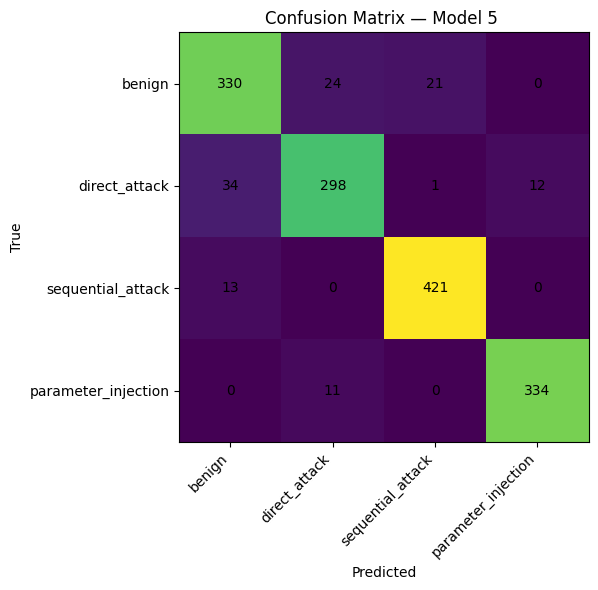

In [27]:
cm = confusion_matrix(test_labels, test_predictions)
fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(cm)
ax.set_title("Confusion Matrix — Model 5 ")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(target_names, rotation=45, ha="right")
ax.set_yticklabels(target_names)
for i in range(cm.shape[0]):
  for j in range(cm.shape[1]):
    ax.text(j, i, str(cm[i, j]), ha="center", va="center")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "confusion_matrix_model5_selective_fusion.png", dpi=150)
plt.show()

### 9.5 Training Curve

Cell ini menampilkan kurva loss dan weighted F1 selama training.

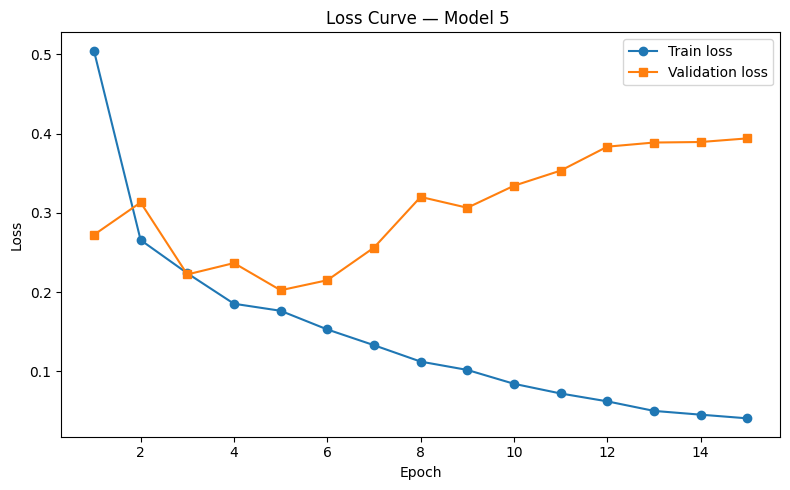

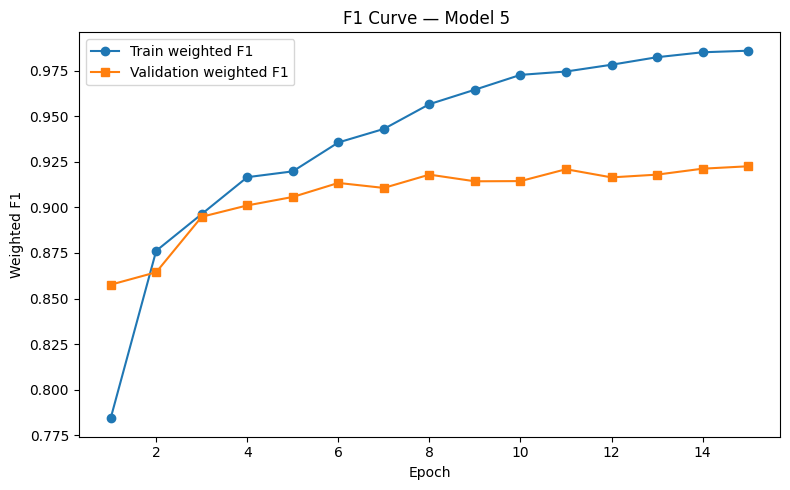

In [28]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], marker="o", label="Train loss")
plt.plot(epochs, history["val_loss"], marker="s", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve — Model 5 ")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "loss_curve_model5_selective_fusion.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_f1"], marker="o", label="Train weighted F1")
plt.plot(epochs, history["val_f1"], marker="s", label="Validation weighted F1")
plt.xlabel("Epoch")
plt.ylabel("Weighted F1")
plt.title("F1 Curve — Model 5 ")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "f1_curve_model5_selective_fusion.png", dpi=150)
plt.show()

## 10. Export Ringkasan Hasil

Bagian ini menyimpan konfigurasi dan metrik utama ke JSON agar mudah dipakai untuk tabel perbandingan model.

### 10.1 Simpan Summary JSON

Cell ini menyimpan hasil akhir eksperimen.

In [29]:
summary = {
  "model_name": "Model 5 Selective Semi-Frozen Fusion",
  "training_strategy": "selective_semifrozen_whole_sequence_branch",
  "config": {
    "encoder_model": ENCODER_MODEL,
    "max_seq_len": MAX_SEQ_LEN,
    "max_tool_calls": MAX_TOOL_CALLS,
    "batch_size": BATCH_SIZE,
    "learning_rate_bert": LEARNING_RATE_BERT,
    "learning_rate_head": LEARNING_RATE_HEAD,
    "num_epochs": NUM_EPOCHS,
    "weight_decay": WEIGHT_DECAY,
    "early_stop": EARLY_STOP,
    "unfreeze_last_n_layers": UNFREEZE_LAST_N_LAYERS,
    "lstm_hidden_size": LSTM_HIDDEN_SIZE,
    "lstm_num_layers": LSTM_NUM_LAYERS,
    "fusion_dim": FUSION_DIM,
  },
  "test_metrics": {
    "accuracy": float(test_accuracy),
    "macro_f1": float(macro_f1),
    "weighted_f1": float(weighted_f1),
    "asr": float(safety_metrics["asr"]),
    "benign_fpr": float(safety_metrics["benign_fpr"]),
    "test_loss": float(test_loss),
  },
  "classification_report": report,
  "confusion_matrix": cm.tolist(),
}

summary_path = OUTPUT_DIR / "results_summary_model5_selective_fusion.json"
with open(summary_path, "w", encoding="utf-8") as file:
  json.dump(summary, file, indent=2)

print("Saved:", summary_path)

Saved: outputs/results_summary_model5_selective_fusion.json


## 11. Catatan Interpretasi

 tidak sama dengan frozen feature extractor penuh. Model ini melakukan fine-tuning terbatas hanya pada whole-sequence BERT branch, sementara context embedding dan per-tool-call sequence embedding tetap frozen dan di-cache.

Interpretasi untuk laporan:

Model 5 merupakan selective semi-frozen fusion model. Whole-sequence branch diadaptasi ke domain tool-call safety dengan membuka beberapa layer terakhir BERT, sedangkan sequence branch tetap memakai frozen BERT embedding yang diproses oleh BiLSTM dan attention pooling. Strategi ini dipilih untuk meningkatkan performa dibanding frozen fusion tanpa mengulang biaya komputasi end-to-end pada setiap tool call.